In [4]:
pip install nilearn scikit-learn pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
import numpy as np
from nilearn import datasets

print("⏳ Buscando niños varones de 5 a 10 años en toda la base de datos ABIDE...")

# Traemos la información base de todos los sujetos (n_subjects=None)
# Al no pedirle pipelines de imágenes, solo maneja la tabla clínica de texto
data_completa = datasets.fetch_abide_pcp(n_subjects=None)
df_clinico = pd.DataFrame(data_completa.phenotypic)

# Aplicamos los filtros en Pandas: Varones (1) entre 5 y 10 años
filtro_especifico = (df_clinico['SEX'] == 1) & (df_clinico['AGE_AT_SCAN'] >= 5.0) & (df_clinico['AGE_AT_SCAN'] <= 10.0)
df_filtrado = df_clinico[filtro_especifico]

# Nos quedamos con los primeros 200 niños que cumplen la condición
df_200_ninos = df_filtrado.head(200)
pacientes_validos_ids = df_200_ninos['SUB_ID'].tolist()

print(f"\n✅ ¡Búsqueda completada con éxito!")
print(f"📊 Se encontraron {len(df_filtrado)} niños en total en la base de datos.")
print(f"🎯 Seleccionamos los primeros {len(pacientes_validos_ids)} para el entrenamiento.")

⏳ Buscando niños varones de 5 a 10 años en toda la base de datos ABIDE...


[fetch_abide_pcp] Dataset found in C:\Users\luna_\nilearn_data\ABIDE_pcp

[fetch_abide_pcp] Downloading data from 
https://s3.amazonaws.com/fcp-indi/data/Projects/ABIDE_Initiative/Outputs/cpac/nofilt_noglobal/func_preproc/UCLA_1_0
051280_func_preproc.nii.gz ...

[fetch_abide_pcp] Downloaded 18767872 of 73440975 bytes (25.6%%,   28.0s remaining)

[fetch_abide_pcp] Downloaded 33775616 of 73440975 bytes (46.0%%,    4.9s remaining)

...

[fetch_abide_pcp] Downloaded 31014912 of 65748493 bytes (47.2%%,    3.6s remaining)

[fetch_abide_pcp] Downloaded 48136192 of 65748493 bytes (73.2%%,    1.5s remaining)

[fetch_abide_pcp] Downloaded 63651840 of 65748493 bytes (96.8%%,    0.2s remaining)

[fetch_abide_pcp]  ...done. (6 seconds, 0 min)


✅ ¡Búsqueda completada con éxito!
📊 Se encontraron 79 niños en total en la base de datos.
🎯 Seleccionamos los primeros 79 para el entrenamiento.


In [10]:
print(f"⏳ Descargando los {len(pacientes_validos_ids)} escaneos cerebrales específicos del servidor...")

# Descargamos los datos funcionales pasando la lista exacta de IDs en 'SUB_ID'
data_triplet = datasets.fetch_abide_pcp(
    SUB_ID=pacientes_validos_ids,
    pipeline="cpac",
    quality_checked=True
)

# Creamos las etiquetas de diagnóstico 'y' sincronizadas con esta descarga oficial
df_final_cohort = pd.DataFrame(data_triplet.phenotypic)
y = np.where(df_final_cohort['DX_GROUP'] == 1, 1, 0)

print("\n📊 DISTRIBUCIÓN REAL DE LA COHORTE FILTRADA:")
print(f"Total de niños descargados: {len(y)}")
print(f"🧩 Casos dentro del espectro (Clase 1): {sum(y)}")
print(f"🧠 Casos de control neurotípicos (Clase 0): {len(y) - sum(y)}")

df_final_cohort[['SUB_ID', 'AGE_AT_SCAN', 'SEX', 'DX_GROUP']].head(5)

⏳ Descargando los 79 escaneos cerebrales específicos del servidor...


[fetch_abide_pcp] Dataset found in C:\Users\luna_\nilearn_data\ABIDE_pcp


📊 DISTRIBUCIÓN REAL DE LA COHORTE FILTRADA:
Total de niños descargados: 79
🧩 Casos dentro del espectro (Clase 1): 38
🧠 Casos de control neurotípicos (Clase 0): 41


,SUB_ID,AGE_AT_SCAN,SEX,DX_GROUP
11,50013,9.33,1,1
50,50054,9.44,1,2
61,50106,10.00,1,2
97,50146,8.00,1,1
101,50150,9.42,1,1


In [7]:
# Miramos qué variables reales se crearon dentro de tu descarga limpia
print("📋 CLAVES REALES DISPONIBLES EN TU OBJETO:")
keys_reales = list(data_triplet.keys())
print(keys_reales)

# Buscamos de forma segura si hay algo que contenga la palabra 'rois' o 'func'
encontrados = [k for k in keys_reales if 'roi' in k or 'func' in k]
print(f"\n📌 Variables de mapas cerebrales detectadas: {encontrados}")

📋 CLAVES REALES DISPONIBLES EN TU OBJETO:
['description', 'phenotypic', 'func_preproc']

📌 Variables de mapas cerebrales detectadas: ['func_preproc']


In [12]:
import os
import warnings
from nilearn.maskers import NiftiLabelsMasker
from nilearn import datasets as nilearn_datasets
from nilearn.connectome import ConnectivityMeasure
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# 1. Silenciamos advertencias futuras para que la consola quede limpia
warnings.filterwarnings("ignore", category=FutureWarning)

print("🗺️ 1. Cargando el atlas cerebral Harvard-Oxford...")
atlas = nilearn_datasets.fetch_atlas_harvard_oxford('cort-maxprob-thr25-2mm')
atlas_filename = atlas.maps

# Usamos 'zscore_sample' directo para evitar que Nilearn se queje
masker = NiftiLabelsMasker(labels_img=atlas_filename, standardize='zscore_sample', memory="nilearn_cache")

print("\n⏳ 2. Extrayendo señales numéricas (Procesando escaneos 3D)...")
time_series_list = []
total_pacientes = len(data_triplet.func_preproc)

for i, archivo_cerebro in enumerate(data_triplet.func_preproc):
    # Imprime el progreso en la misma línea
    print(f" 🧩 Procesando paciente {i+1}/{total_pacientes}...", end="\r")
    signals = masker.fit_transform(archivo_cerebro)
    time_series_list.append(signals)

print("\n\n🧠 3. Calculando matrices de conectividad funcional (X)...")
conn_measure = ConnectivityMeasure(kind='correlation', vectorize=True)
X = conn_measure.fit_transform(time_series_list)
print(f"📐 Tamaño final de la matriz X: {X.shape}")

# EXTRA: Guardamos X e y localmente en tu carpeta para no tener que recalcular nunca más
np.save('X_conectividad.npy', X)
np.save('y_diagnostico.npy', y)
print("💾 ¡Matrices respaldadas localmente como archivos .npy!")

print("\n✂️ 4. Dividiendo el dataset (80% Train / 20% Test)...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("⚖️ 5. Escalando características...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("🤖 6. Entrenando el modelo de Machine Learning (Regresión Logística)...")
model = LogisticRegression(C=0.1, penalty='l2', max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print("\n🎯 --- RESULTADOS DEL MODELO PILOTO ---")
print(f"Precisión General (Accuracy): {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\n📝 Reporte de Clasificación Detallado:")
print(classification_report(y_test, y_pred, target_names=['Control (0)', 'Autismo (1)']))

🗺️ 1. Cargando el atlas cerebral Harvard-Oxford...


[fetch_atlas_harvard_oxford] Dataset found in C:\Users\luna_\nilearn_data\fsl


⏳ 2. Extrayendo señales numéricas (Procesando escaneos 3D)...
 🧩 Procesando paciente 79/79...

🧠 3. Calculando matrices de conectividad funcional (X)...
📐 Tamaño final de la matriz X: (79, 1176)
💾 ¡Matrices respaldadas localmente como archivos .npy!

✂️ 4. Dividiendo el dataset (80% Train / 20% Test)...
⚖️ 5. Escalando características...
🤖 6. Entrenando el modelo de Machine Learning (Regresión Logística)...

🎯 --- RESULTADOS DEL MODELO PILOTO ---
Precisión General (Accuracy): 68.75%

📝 Reporte de Clasificación Detallado:
              precision    recall  f1-score   support

 Control (0)       0.71      0.62      0.67         8
 Autismo (1)       0.67      0.75      0.71         8

    accuracy                           0.69        16
   macro avg       0.69      0.69      0.69        16
weighted avg       0.69      0.69      0.69        16



📊 Generando Matriz de Confusión...
🧠 Generando Mapa de Calor de Conectividad...


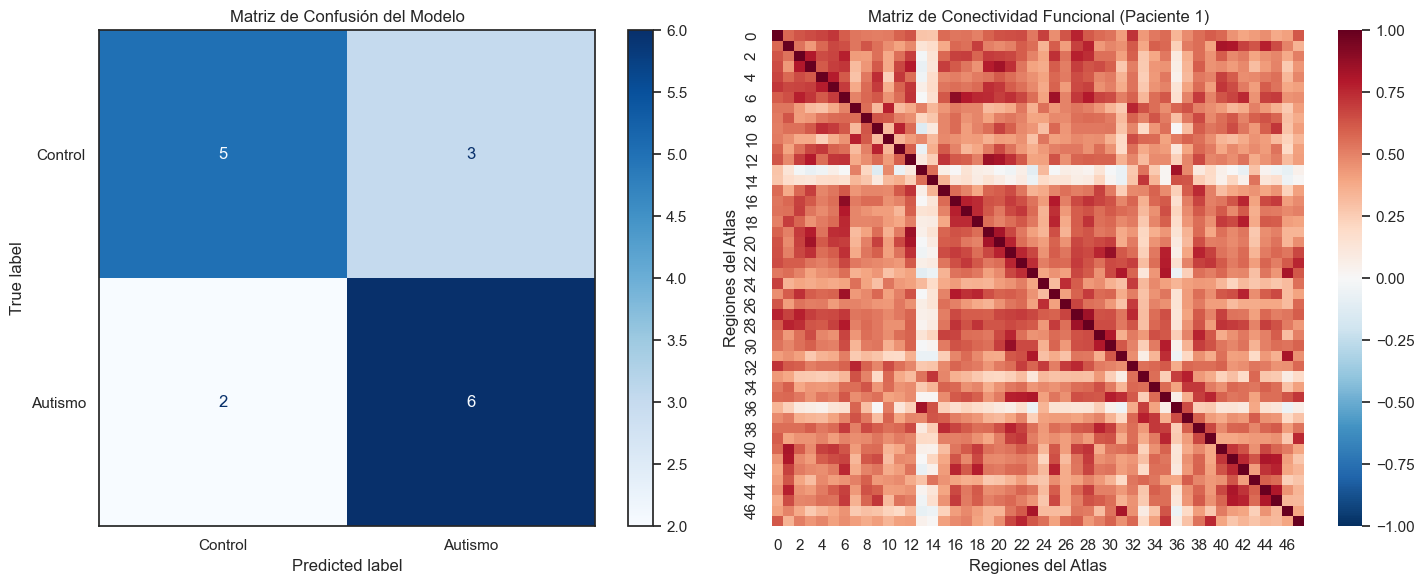

✨ Generando Conectoma Cerebral 3D...


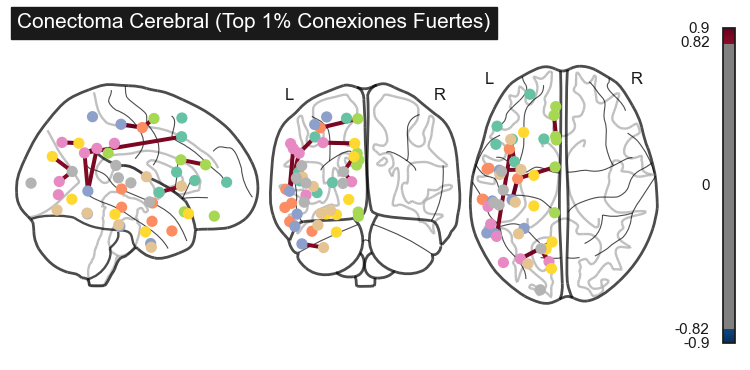

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from nilearn import plotting

# Configurar el estilo de los gráficos
sns.set_theme(style="white")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- GRÁFICO 1: Matriz de Confusión ---
print("📊 Generando Matriz de Confusión...")
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Control', 'Autismo'])
disp.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title('Matriz de Confusión del Modelo')

# --- GRÁFICO 2: Matriz de Conectividad (Heatmap) ---
print("🧠 Generando Mapa de Calor de Conectividad...")

# En lugar de importar funciones, usamos el método native 'inverse_transform' de tu conn_measure
# Le pasamos solo la primera fila (el primer paciente) para reconstruir su matriz de 48x48
matriz_cuadrada_3d = conn_measure.inverse_transform(X[0:1]) 
# Extraemos la matriz 2D (quitando la dimensión extra que genera el lote)
matriz_cuadrada = matriz_cuadrada_3d[0]

sns.heatmap(matriz_cuadrada, ax=axes[1], cmap='RdBu_r', vmin=-1, vmax=1, center=0)
axes[1].set_title('Matriz de Conectividad Funcional (Paciente 1)')
axes[1].set_xlabel('Regiones del Atlas')
axes[1].set_ylabel('Regiones del Atlas')

plt.tight_layout()
plt.show()

# --- GRÁFICO 3: Conectoma en el Cerebro (Glass Brain) ---
print("✨ Generando Conectoma Cerebral 3D...")
# Obtenemos las coordenadas 3D del centro de cada región del atlas
coordenadas_regiones = plotting.find_parcellation_cut_coords(labels_img=atlas_filename)

# Graficamos el cerebro transparente mostrando solo las conexiones más fuertes (top 1%)
plotting.plot_connectome(
    adjacency_matrix=matriz_cuadrada,
    node_coords=coordenadas_regiones,
    edge_threshold="99%",  # Solo muestra el 1% de las conexiones más fuertes
    title="Conectoma Cerebral (Top 1% Conexiones Fuertes)",
    display_mode='ortho'   # Muestra corte sagital, axial y coronal
)
plotting.show()

🧠 Separando datos por grupos diagnósticos...
📊 Cantidad de muestras para promediar -> Controles: 41 | Autismo: 38
🎨 Generando Mapas de Calor Comparativos...


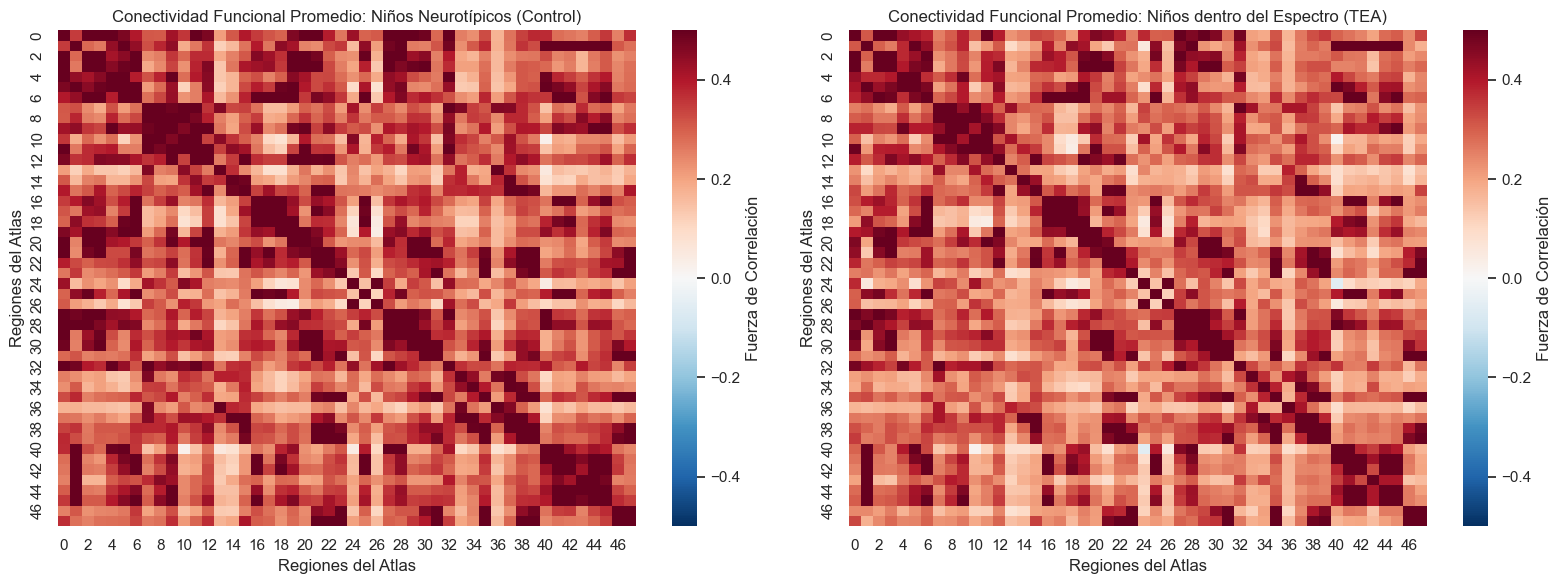

📉 Calculando la Matriz de Contraste (Autismo - Control)...


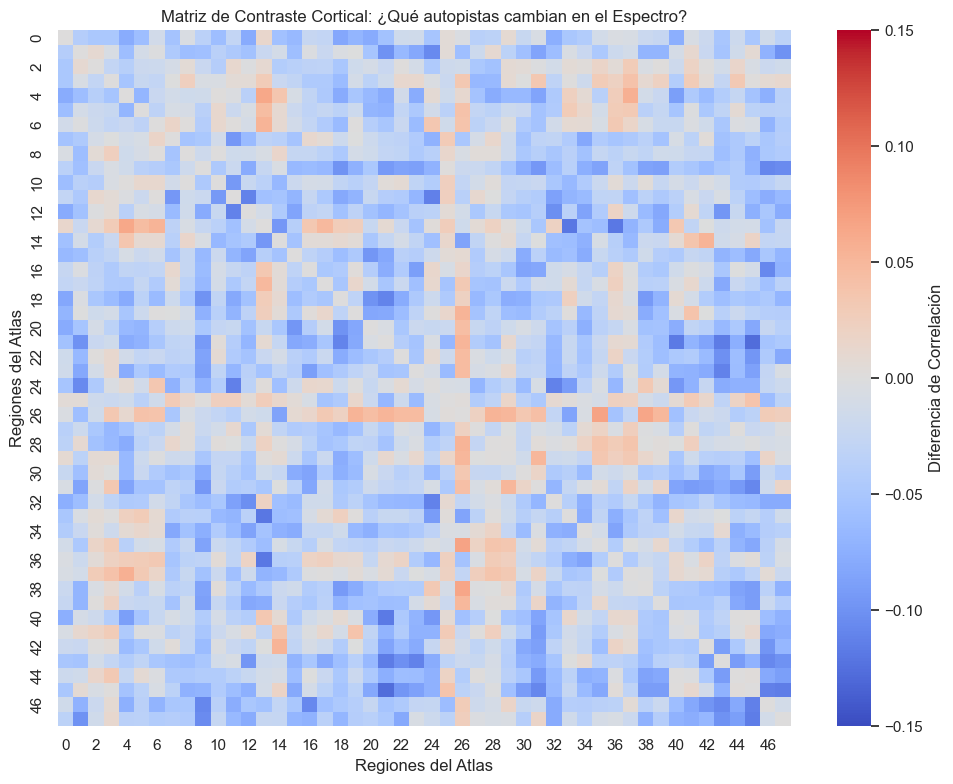

✨ Dibujando Conectomas 3D en Cerebros Transparentes...


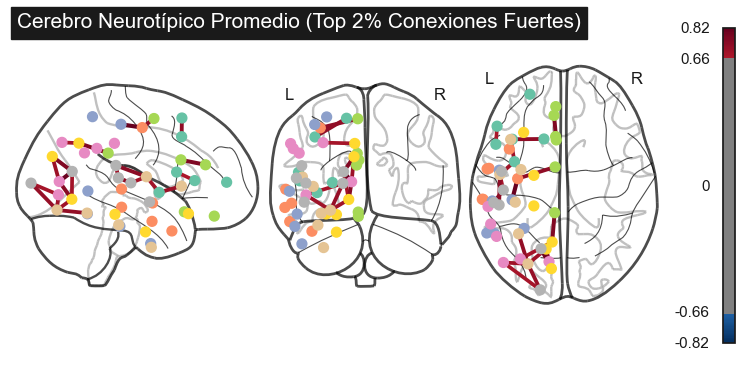

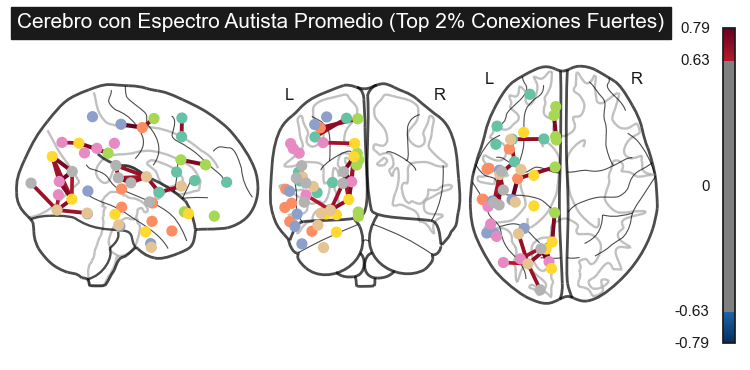

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from nilearn import plotting

print("🧠 Separando datos por grupos diagnósticos...")
# 1. Separamos las características (X) según las etiquetas (y)
X_control = X[y == 0]
X_autismo = X[y == 1]

print(f"📊 Cantidad de muestras para promediar -> Controles: {X_control.shape[0]} | Autismo: {X_autismo.shape[0]}")

# 2. Calculamos el vector "promedio" para cada grupo humano
mean_control_vec = np.mean(X_control, axis=0)
mean_autismo_vec = np.mean(X_autismo, axis=0)

# 3. Reconstruimos las matrices cuadradas de 48x48 usando tu conn_measure
matrix_control = conn_measure.inverse_transform(mean_control_vec[np.newaxis, :])[0]
matrix_autismo = conn_measure.inverse_transform(mean_autismo_vec[np.newaxis, :])[0]

# --- GRÁFICO 1: Mapas de Calor Lado a Lado ---
print("🎨 Generando Mapas de Calor Comparativos...")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Usamos la misma escala vmin/vmax para que la comparación visual sea honesta
sns.heatmap(matrix_control, ax=axes[0], cmap='RdBu_r', vmin=-0.5, vmax=0.5, center=0, cbar_kws={'label': 'Fuerza de Correlación'})
axes[0].set_title('Conectividad Funcional Promedio: Niños Neurotípicos (Control)')
axes[0].set_xlabel('Regiones del Atlas')
axes[0].set_ylabel('Regiones del Atlas')

sns.heatmap(matrix_autismo, ax=axes[1], cmap='RdBu_r', vmin=-0.5, vmax=0.5, center=0, cbar_kws={'label': 'Fuerza de Correlación'})
axes[1].set_title('Conectividad Funcional Promedio: Niños dentro del Espectro (TEA)')
axes[1].set_xlabel('Regiones del Atlas')
axes[1].set_ylabel('Regiones del Atlas')

plt.tight_layout()
plt.show()

# --- GRÁFICO 2: Matriz de Contraste (Diferencia Absoluta) ---
print("📉 Calculando la Matriz de Contraste (Autismo - Control)...")
# Restamos las dos matrices. Los valores positivos (rojo) significan hiperconectividad en TEA.
# Los valores negativos (azul) significan hipoconectividad en TEA.
matrix_contraste = matrix_autismo - matrix_control

plt.figure(figsize=(10, 8))
sns.heatmap(matrix_contraste, cmap='coolwarm', vmin=-0.15, vmax=0.15, center=0, cbar_kws={'label': 'Diferencia de Correlación'})
plt.title('Matriz de Contraste Cortical: ¿Qué autopistas cambian en el Espectro?')
plt.xlabel('Regiones del Atlas')
plt.ylabel('Regiones del Atlas')
plt.tight_layout()
plt.show()

# --- GRÁFICO 3: Conectomas 3D Comparativos (Glass Brains) ---
print("✨ Dibujando Conectomas 3D en Cerebros Transparentes...")
# Buscamos las coordenadas espaciales del atlas
coordenadas_regiones = plotting.find_parcellation_cut_coords(labels_img=atlas_filename)

# Graficamos el conectoma promedio de Control
plotting.plot_connectome(
    adjacency_matrix=matrix_control,
    node_coords=coordenadas_regiones,
    edge_threshold="98%", # Top 2% de conexiones más intensas
    title="Cerebro Neurotípico Promedio (Top 2% Conexiones Fuertes)"
)
plotting.show()

# Graficamos el conectoma promedio de Autismo
plotting.plot_connectome(
    adjacency_matrix=matrix_autismo,
    node_coords=coordenadas_regiones,
    edge_threshold="98%",
    title="Cerebro con Espectro Autista Promedio (Top 2% Conexiones Fuertes)"
)
plotting.show()